# Decision Tree Classifier di KNIME

## 1. Pendahuluan
Decision Tree adalah salah satu algoritma supervised learning yang digunakan untuk klasifikasi maupun regresi. Di KNIME, kita menggunakan node Decision Tree Learner untuk membangun model klasifikasi berdasarkan dataset. Algoritma ini bekerja dengan memecah data ke dalam cabang-cabang berdasarkan fitur yang paling informatif, sehingga mempermudah prediksi kelas target.

## 2. Konsep Dasar Pohon Keputusan

### 2.1 Struktur Pohon
Pohon keputusan terdiri dari tiga elemen utama:
- **Root Node:** Titik awal pohon, biasanya fitur yang paling memisahkan kelas target.
- **Internal Node:** Fitur yang digunakan untuk split lebih lanjut. Setiap cabang menunjukkan kondisi atau aturan pada fitur tersebut.
- **Leaf Node:** Node akhir yang menunjukkan hasil prediksi kelas.

### 2.2 Cara Kerja
1. Algoritma menghitung ukuran ketidakmurnian (*impurity*) untuk setiap fitur.
2. Fitur dengan ukuran informasi tertinggi dipilih sebagai titik split.
3. Data dibagi menjadi subset sesuai aturan split.
4. Proses ini diulang hingga kriteria berhenti tercapai, misalnya:
   - Semua data di node sudah murni
   - Jumlah data di node lebih kecil dari threshold minimal


## 3. Ukuran untuk Split: Gain Ratio

### 3.1 Entropy
Entropy digunakan untuk mengukur **ketidakpastian** data sebelum split:

$$
Entropy(S) = -\sum_{i=1}^{k} p_i \log_2(p_i)
$$


di mana $(p_i$) adalah proporsi data kelas ke-i dalam dataset S.

### 3.2 Information Gain
Information Gain mengukur peningkatan informasi setelah split:


$$
IG(F) = Entropy(S) - \sum_{v \in Values(F)} \frac{|S_v|}{|S|} \cdot Entropy(S_v)
$$


- S_v adalah subset data setelah split dengan nilai v pada fitur F.
- Semakin tinggi IG, fitur semakin baik memisahkan kelas.



### 3.3 Gain Ratio
Gain Ratio dihitung dengan:


$$
GainRatio(F) = \frac{IG(F)}{SI(F)}
$$


- Mengurangi bias Information Gain terhadap fitur dengan banyak kategori.
- Memilih fitur yang benar-benar informatif untuk split.

---

## 4. Implementasi di KNIME

### 4.1 Alur Node
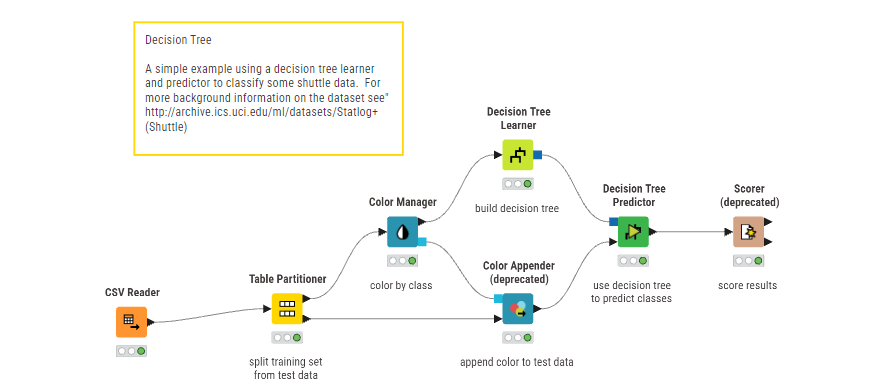

1. **CSV Reader:**
- Node pertama untuk membaca dataset dari file CSV.  
- Pastikan dataset sudah bersih dan kolom target sudah dikategorikan (categorical).

2. **Table Partitioner:**
- Membagi dataset menjadi training set dan test set.  
- Setting
  - Relative Size: 33 (33% data menjadi test)  
  - Sampling Strategy: Stratified → menjaga proporsi kelas tetap sama  
  - Group Column: kolom target (misal `Drug`) agar KNIME tahu kelas mana yang harus dipertahankan proporsinya.

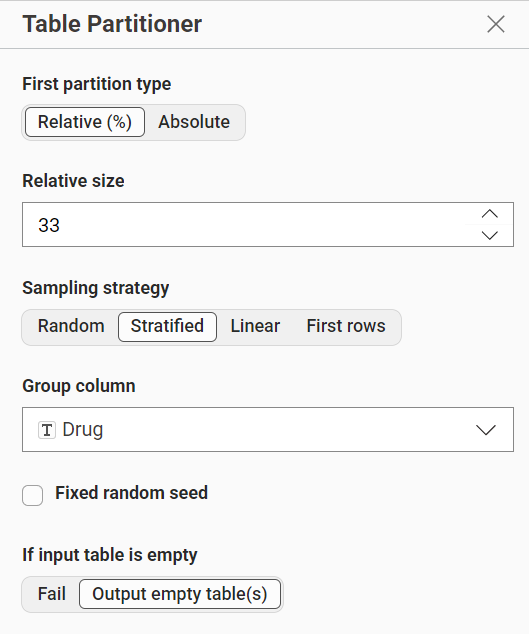

3. **Color Manager:** Opsional, Memberi warna ke data berdasarkan kelas target agar mempermudah visualisasi distribusi kelas sebelum membangun model; membantu melihat apakah ada class imbalance.


4. **Color Appender (deprecated)**  
digunakan untuk menambahkan warna pada dataset test berdasarkan kolom target, misalnya `Drug`. Node ini bersifat opsional dan hanya untuk visualisasi, sehingga tidak mengubah prediksi model atau perhitungan akurasi.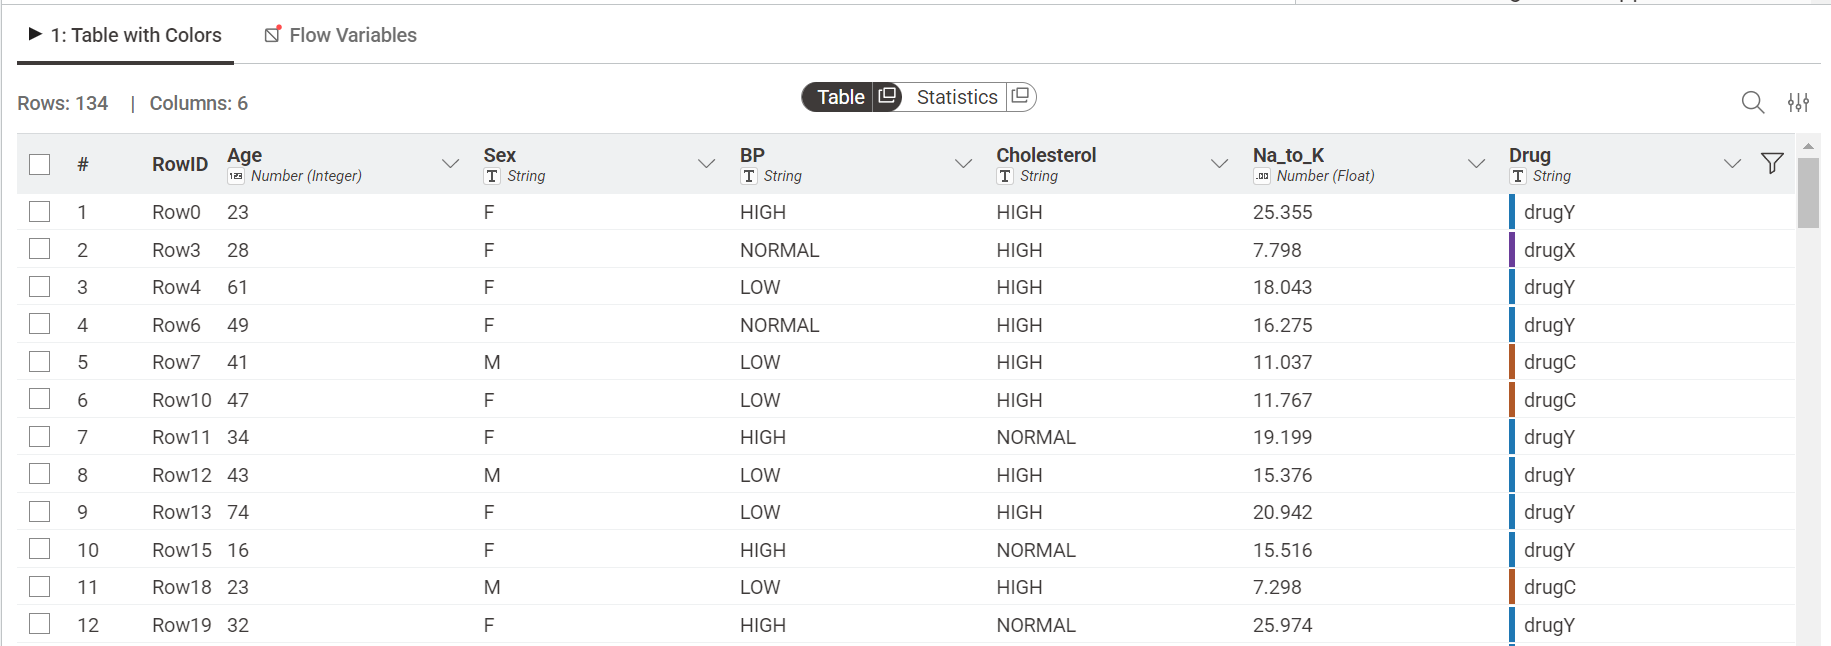

Hasil tabel  menunjukkan setiap record data test dengan fitur input (`Age`, `Sex`, `BP`, `Cholesterol`, `Na_to_K`) dan kolom target `Drug`. Warna pada kolom `Drug` menandakan kategori masing-masing kelas, sehingga mudah membedakan kelas `drugY`, `drugX`, `drugC`, `drugA`, dan `drugB`.  

Visualisasi warna ini memudahkan melihat distribusi kelas, mengidentifikasi kelas minor, dan membandingkan kelas target asli dengan prediksi model secara intuitif sebelum evaluasi formal dengan Confusion Matrix atau Scorer.



5. **Decision Tree Learner:**  

# Decision Tree Learner di KNIME

Decision Tree Learner digunakan untuk membangun pohon klasifikasi dari data training dengan target `Drug`. Split criterion dipilih **Gain Ratio** agar fitur paling informatif dipakai dan tidak bias terhadap fitur kategori banyak. **No pruning** dipakai, tapi **Reduced Error Pruning** aktif untuk mengurangi overfitting. **Minimum records per node = 1** agar pohon bisa bercabang maksimal. **Number of records to store = 10.000** untuk visualisasi, dan **Number of threads = 12** mempercepat proses. Average Split Point tidak dicentang agar split mengikuti nilai asli fitur.

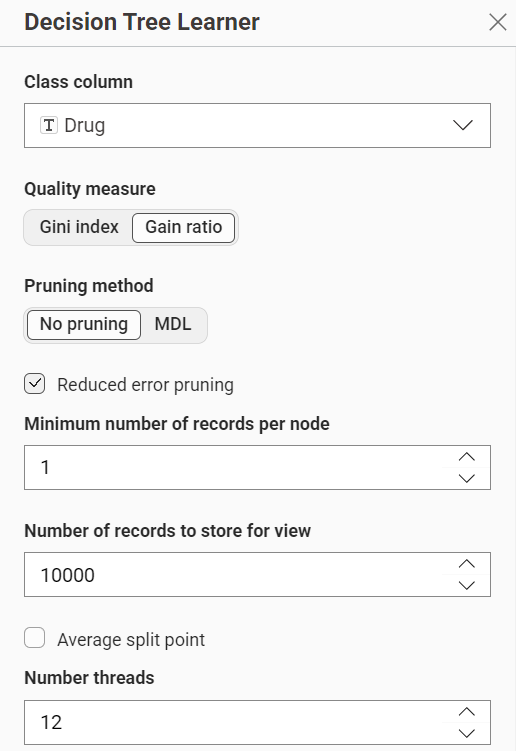


**Hasil Tree**

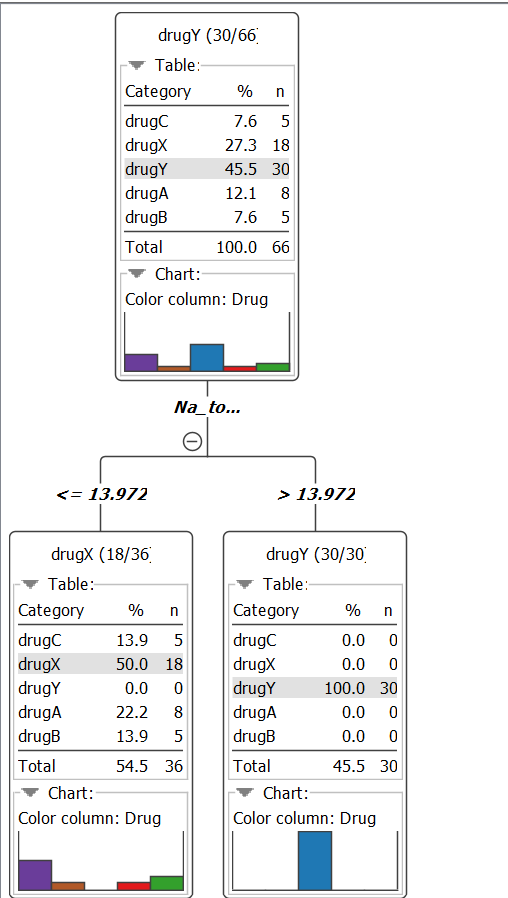



Pohon keputusan ini menunjukkan bagaimana model Decision Tree memprediksi kelas `Drug` berdasarkan fitur `Na_to_K`. Root node menampilkan distribusi awal semua kelas, di mana `drugY` adalah kelas terbesar (45,5%), diikuti `drugX`, `drugA`, `drugC`, dan `drugB`.

Pohon kemudian terbagi berdasarkan threshold `Na_to_K <= 13.972` dan `> 13.972`.

- Cabang kiri (`<= 13.972`) berisi 36 record. Di sini, `drugX` menjadi kelas dominan dengan 50% record, diikuti `drugA` (22,2%), serta `drugC` dan `drugB` masing-masing 13,9%. Cabang ini menunjukkan kombinasi fitur yang membuat model memprediksi kelas campuran, sehingga prediksi tidak 100% akurat untuk satu kelas saja.

- Cabang kanan (`> 13.972`) berisi 30 record. Semua record di cabang ini termasuk kelas `drugY` (100%). Artinya, untuk nilai `Na_to_K` lebih dari 13.972, model yakin memprediksi `drugY`.

Setiap node menampilkan tabel distribusi kelas dan chart warna untuk mempermudah visualisasi. Dengan pohon ini, dapat dilihat bagaimana model memisahkan record berdasarkan threshold `Na_to_K` dan bagaimana probabilitas setiap kelas berubah di tiap cabang. Cabang kanan murni (pure), sedangkan cabang kiri mengandung beberapa kelas, menunjukkan potensi ketidakpastian prediksi di situ.




6. **Decision Tree Predictor:**

Decision Tree Predictor digunakan untuk memprediksi kelas target (`Drug`) pada data test menggunakan model yang sudah dibangun oleh Decision Tree Learner. Node ini menambahkan kolom prediksi baru (`Prediction (Drug)`) ke dataset, sehingga kita bisa langsung membandingkan kelas asli dengan hasil prediksi.

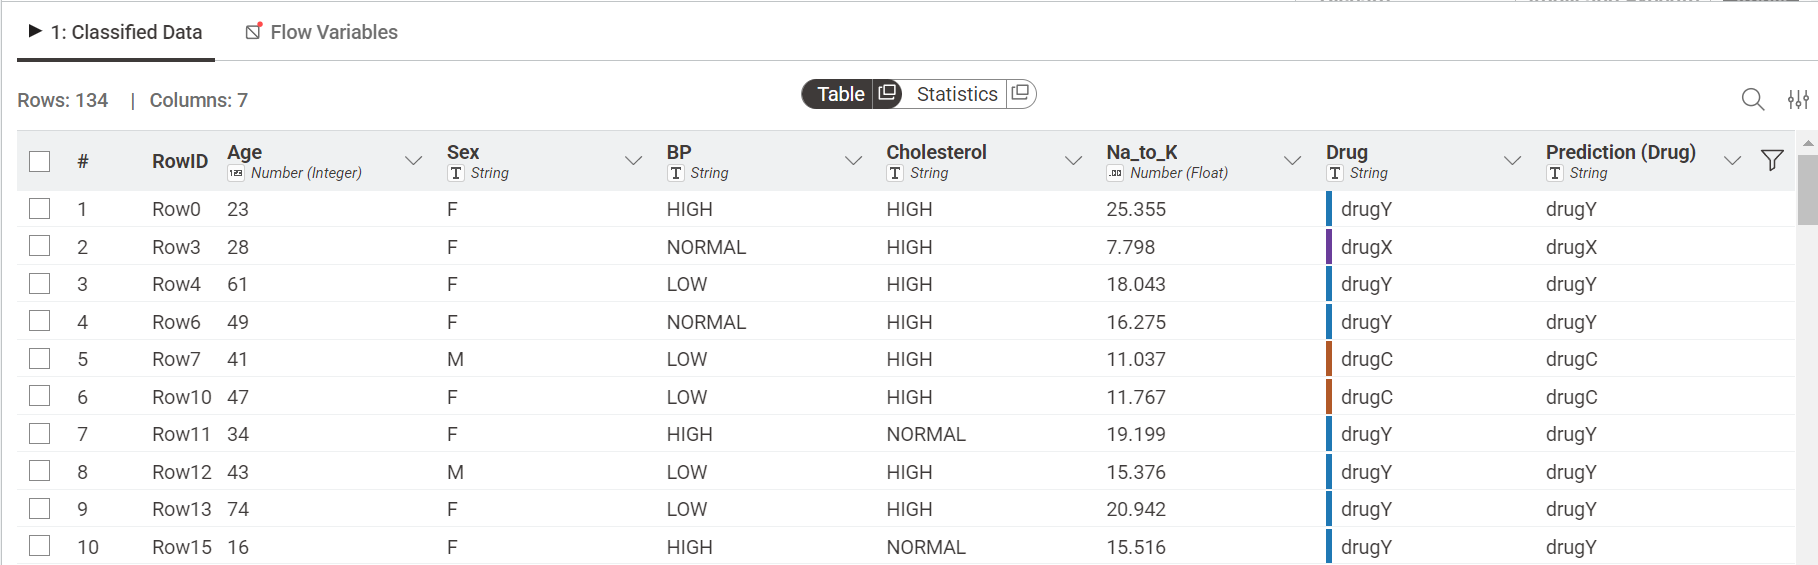


Tabel menunjukkan setiap record dengan fitur input (`Age`, `Sex`, `BP`, `Cholesterol`, `Na_to_K`), kolom target `Drug`, dan kolom prediksi model. Dari tabel terlihat sebagian besar record diprediksi sesuai kelas asli, misalnya `drugY` diprediksi sebagai `drugY`, `drugC` diprediksi sebagai `drugC`, dan seterusnya. Hasil ini menunjukkan model Decision Tree bekerja baik, dan kolom prediksi siap digunakan untuk evaluasi akurasi dengan **Scorer** atau analisis Confusion Matrix.



7. **Scorer / Confusion Matrix:**

digunakan untuk mengevaluasi kinerja model klasifikasi. Node ini membandingkan kelas asli (target) dengan kelas prediksi dari Decision Tree Predictor atau model lain, kemudian menghasilkan metrik evaluasi seperti akurasi, True Positive, False Positive, False Negative, dan True Negative.

**Hasil Confusion Matrix:**

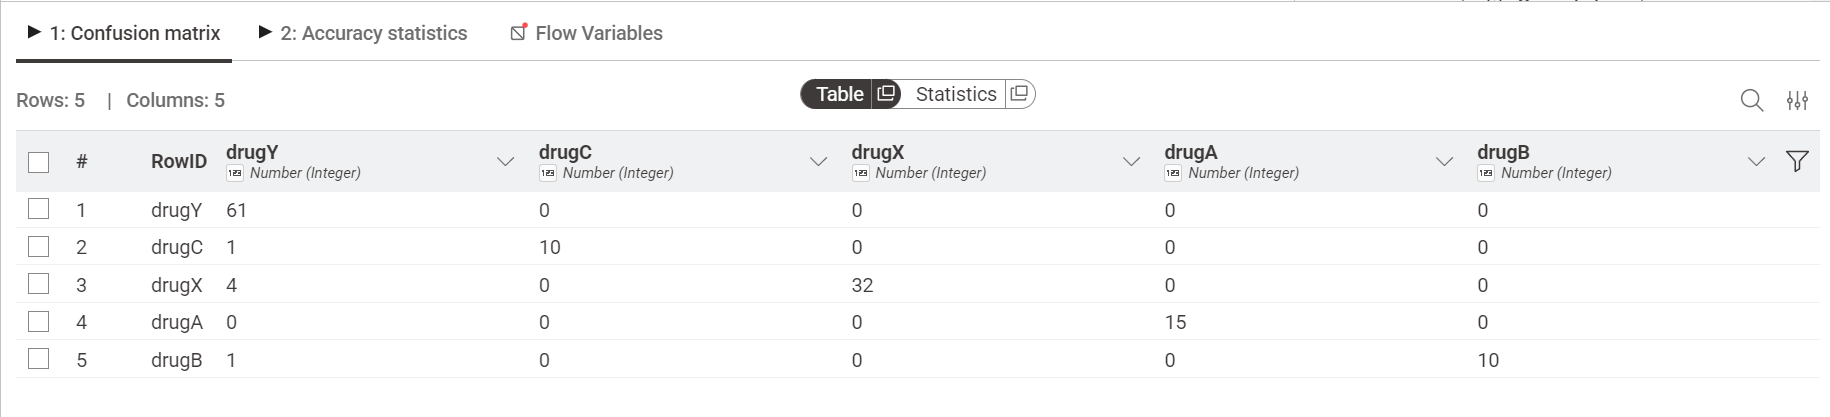


Confusion Matrix ini menunjukkan performa model Decision Tree dalam memprediksi kelas `Drug`. Baris mewakili kelas asli, sedangkan kolom menunjukkan kelas yang diprediksi oleh model.

- **drugY**: dari 61 record sebenarnya `drugY`, semua diprediksi dengan benar sebagai `drugY`.  
- **drugC**: dari 11 record sebenarnya `drugC`, 10 diprediksi benar, 1 salah diprediksi sebagai `drugY`.  
- **drugX**: dari 36 record sebenarnya `drugX`, 32 diprediksi benar, 4 salah diprediksi sebagai `drugY`.  
- **drugA**: semua 15 record diprediksi dengan benar sebagai `drugA`.  
- **drugB**: dari 11 record sebenarnya `drugB`, 10 diprediksi benar, 1 salah diprediksi sebagai `drugY`.

Secara keseluruhan, model Decision Tree memiliki **akurasi tinggi**, sebagian besar record diprediksi dengan benar. Kesalahan minor terjadi pada beberapa kelas (`drugC`, `drugX`, `drugB`), yang bisa dianalisis lebih lanjut untuk perbaikan model. Confusion Matrix ini memudahkan melihat kelas mana yang sering salah diprediksi.

**Hasil Accuracy Statistic**

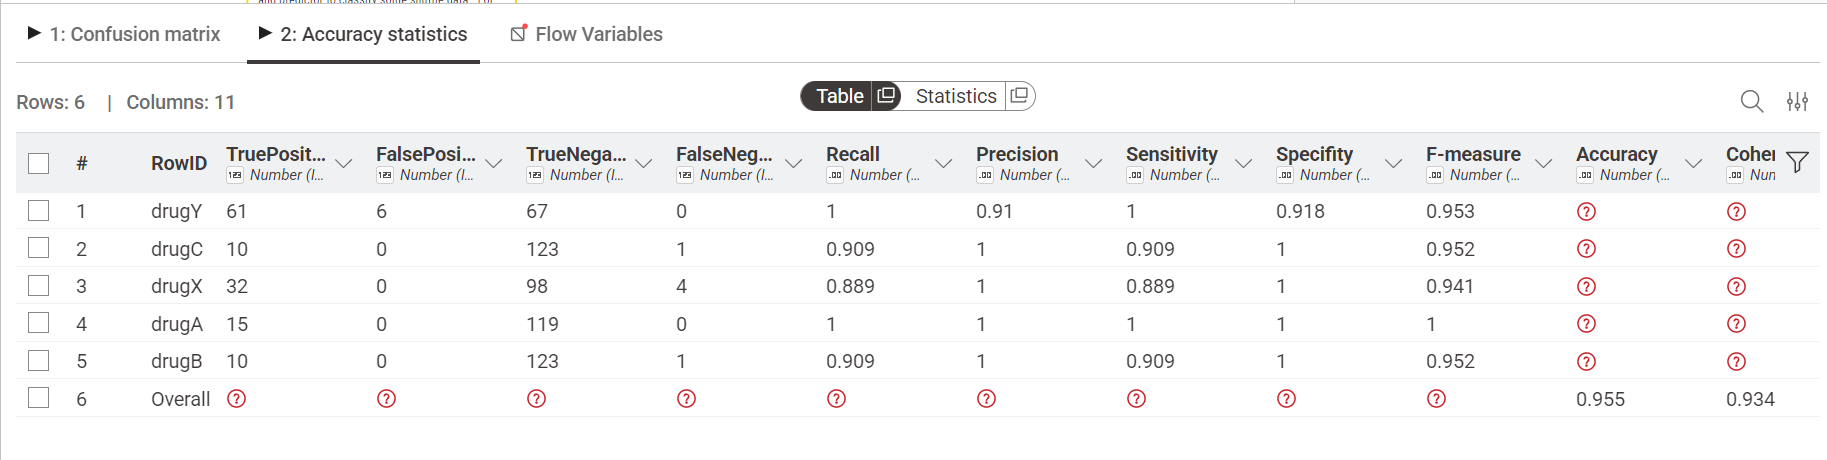



Tabel ini menunjukkan performa model Decision Tree secara keseluruhan. Model mampu memprediksi kelas `Drug` dengan akurasi tinggi sebesar 95,5%. Recall, Precision, dan F-measure untuk masing-masing kelas juga menunjukkan nilai tinggi, menandakan model mampu menangkap dan memprediksi sebagian besar record dengan tepat. Cohens Kappa 0,934 menegaskan kesepakatan prediksi model dengan data asli sangat baik.  

